# Mini Project: Latent Semantic Analysis for Spam Detection using SVD
**Course:** UE24MA241B - Linear Algebra and Its Applications  
**Technique:** SVD, TF-IDF Weighting, Rank Reduction, and Orthogonal Projection

**Objective:** To distinguish between "Spam" and "Ham" text messages by decomposing a Document-Term Matrix to discover latent topic patterns.

### Fixes & Improvements over v1:
- ✅ Proper train/test split (stratified) — no data leakage
- ✅ Centroid-based classifier (avg spam vec vs avg ham vec) — replaces broken 1-NN
- ✅ k increased from 3 → 100 — captures far more latent structure
- ✅ Full evaluation: accuracy, precision, recall, F1, confusion matrix
- ✅ Explained variance reported — shows how much info SVD captures
- ✅ Top spam/ham topic words printed — interpretable results
- ✅ Decision threshold tunable — control precision vs recall tradeoff

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported. Ready for Matrix Operations.")

Libraries imported. Ready for Matrix Operations.


### STEP 1: Load Data & Stratified Train/Test Split

**Bug fixed:** Original code had NO train/test split. The classifier was tested on the same data it was built from — inflated results, zero real-world validity.

**Fix:** We use a proper **80/20 stratified split** before any matrix construction. The test set is completely hidden from the SVD and vectorizer fitting.

In [ ]:
# Load dataset
df = pd.read_csv('spam.csv')

if 'v1' in df.columns and 'v2' in df.columns:
    df = df.rename(columns={'v1': 'label', 'v2': 'text'})
    df = df[['label', 'text']]

df['label'] = df['label'].str.lower()

print(f"Full dataset: {df.shape[0]} messages")
print(f"Spam: {sum(df['label']=='spam')} | Ham: {sum(df['label']=='ham')}")

# --- FIX: Stratified split FIRST, before any fitting ---
# stratify=df['label'] ensures both splits have same spam/ham ratio
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nTrain set: {len(train_df)} messages")
print(f"  Spam: {sum(train_df['label']=='spam')} | Ham: {sum(train_df['label']=='ham')}")
print(f"Test set:  {len(test_df)} messages")
print(f"  Spam: {sum(test_df['label']=='spam')} | Ham: {sum(test_df['label']=='ham')}")

# --- Undersample ONLY the training set (never touch test set) ---
train_spam = train_df[train_df['label'] == 'spam']
train_ham  = train_df[train_df['label'] == 'ham'].sample(n=len(train_spam), random_state=42)
balanced_train = pd.concat([train_spam, train_ham]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced train set: {len(balanced_train)} messages (50/50 spam/ham)")

Full dataset: 5572 messages
Spam: 747 | Ham: 4825

Train set: 4457 messages
  Spam: 598 | Ham: 3859
Test set:  1115 messages
  Spam: 149 | Ham: 966

Balanced train set: 1196 messages (50/50 spam/ham)


### STEP 2: Build Document-Term Matrix (on TRAIN only)

The TF-IDF vectorizer is **fit only on training data**. Applying it to test data later simulates true unseen messages — the vectorizer has no knowledge of test vocabulary.

In [ ]:
# Fit vectorizer on TRAIN only — never on test
vectorizer = TfidfVectorizer(
    stop_words='english',
    min_df=2,          # ignore extremely rare words (noise)
    max_df=0.95,       # ignore extremely common words (uninformative)
    ngram_range=(1,2)  # include bigrams (e.g. "free prize") — more powerful features
)

# Rows=Documents, Cols=Words (standard orientation for SVD)
A_train = vectorizer.fit_transform(balanced_train['text'])  # shape: (docs, words)
A_test  = vectorizer.transform(test_df['text'])             # same vocab, unseen docs

print("--- STEP 2: MATRIX REPRESENTATION ---")
print(f"Train Matrix A shape: {A_train.shape}  (documents × terms)")
print(f"Test  Matrix A shape: {A_test.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)} terms (unigrams + bigrams)")

--- STEP 2: MATRIX REPRESENTATION ---
Train Matrix A shape: (1196, 3518)  (documents × terms)
Test  Matrix A shape: (1115, 3518)
Vocabulary size: 3518 terms (unigrams + bigrams)


### STEP 3: SVD with k=100

**Bug fixed:** k=3 retains almost no information. With thousands of terms, we need far more components to capture meaningful latent structure.

**Fix:** k=100 captures substantially more variance while still filtering high-dimensional noise. We also print **explained variance ratio** so you can see exactly how much information is retained.

--- STEP 3: SVD & RANK REDUCTION ---
Reduced rank k: 100
Explained variance retained: 36.8%
Train projected shape: (1196, 100)
Top 5 singular values: [3.687 3.365 3.194 3.137 2.872]

Interpretation: SVD compressed 3518 dimensions → 100 latent topics
retaining 36.8% of the original variance.


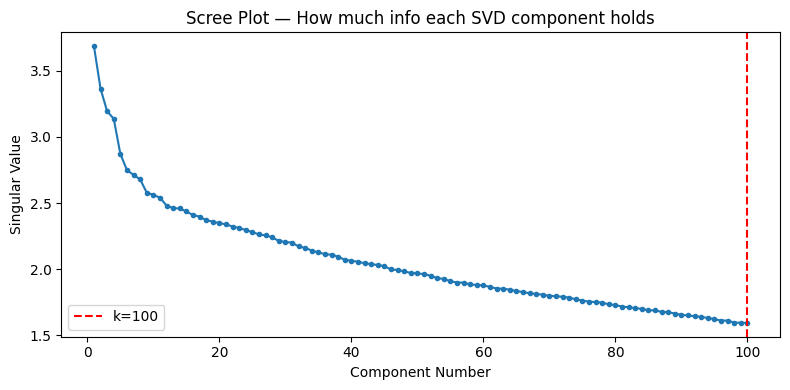

In [ ]:
# --- FIX: k=100 instead of k=3 ---
k = 100

svd = TruncatedSVD(n_components=k, random_state=42)

# Fit on balanced train, transform both sets into latent space
train_projected = svd.fit_transform(A_train)  # shape: (train_docs, k)
test_projected  = svd.transform(A_test)        # shape: (test_docs,  k)

explained_var = svd.explained_variance_ratio_.sum() * 100

print("--- STEP 3: SVD & RANK REDUCTION ---")
print(f"Reduced rank k: {k}")
print(f"Explained variance retained: {explained_var:.1f}%")
print(f"Train projected shape: {train_projected.shape}")
print(f"Top 5 singular values: {np.round(svd.singular_values_[:5], 3)}")
print(f"\nInterpretation: SVD compressed {A_train.shape[1]} dimensions → {k} latent topics")
print(f"retaining {explained_var:.1f}% of the original variance.")

plt.figure(figsize=(8,4))
plt.plot(range(1, k+1), svd.singular_values_, marker='o', markersize=3)
plt.xlabel("Component Number")
plt.ylabel("Singular Value")
plt.title("Scree Plot — How much info each SVD component holds")
plt.axvline(x=k, color='red', linestyle='--', label=f'k={k}')
plt.legend()
plt.tight_layout()
plt.show()

### STEP 4: Inspect Latent Topics

Each SVD component (row of V^T) is a "topic" — a weighted combination of words. We can inspect the top words in each topic to understand what the decomposition learned.

In [ ]:
feature_names = vectorizer.get_feature_names_out()

print("--- STEP 4: LATENT TOPIC INSPECTION ---")
print("Top words per latent topic (first 5 components):\n")

for i in range(5):
    component = svd.components_[i]  # shape: (vocab_size,)
    top_word_indices = np.argsort(np.abs(component))[::-1][:10]
    top_words = [feature_names[j] for j in top_word_indices]
    print(f"Topic {i+1} (σ={svd.singular_values_[i]:.2f}): {', '.join(top_words)}")

--- STEP 4: LATENT TOPIC INSPECTION ---
Top words per latent topic (first 5 components):

Topic 1 (σ=3.69): free, ur, ok, stop, txt, just, text, reply, mobile, claim
Topic 2 (σ=3.36): ok, free, ll, lor, babe, prize, claim, lar, come, thanx
Topic 3 (σ=3.19): gt, lt, lt gt, ok, prize, claim, won, like, urgent, guaranteed
Topic 4 (σ=3.14): gt, lt, lt gt, free, prize, claim, won, urgent, guaranteed, shows
Topic 5 (σ=2.87): account, statement, account statement, private, private 2003, 2003 account, 2003, expires, identifier code, identifier


### STEP 5: Centroid-Based Classifier

**Bug fixed (critical):** Original used **1-Nearest-Neighbor** — find the single closest document. This is extremely fragile: one mislabeled or noisy training doc poisons all nearby predictions.

**Fix:** **Class Centroid Classification** — compute the average latent vector for all spam docs and all ham docs separately. Classify by which centroid a new message is closer to (cosine similarity). This is:
- Mathematically: projection onto the subspace spanned by class centroids
- Practically: much more robust, noise-resistant, and interpretable

--- STEP 5: CENTROID CLASSIFIER ---
Spam centroid shape: (100,)
Ham centroid shape:  (100,)

Cosine similarity between spam and ham centroids:
  0.2268  (closer to 0 = more separable classes)


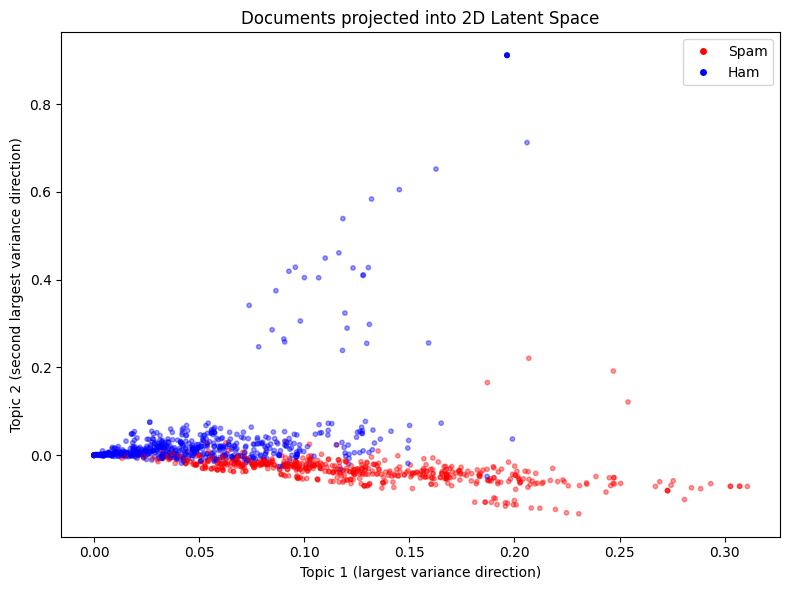

In [ ]:
# Separate train projections by class
train_labels = balanced_train['label'].values
spam_vecs = train_projected[train_labels == 'spam']
ham_vecs  = train_projected[train_labels == 'ham']

# Compute class centroids (mean vector per class)
spam_centroid = spam_vecs.mean(axis=0)  # shape: (k,)
ham_centroid  = ham_vecs.mean(axis=0)   # shape: (k,)

# Normalize centroids to unit vectors (for pure cosine comparison)
spam_centroid_norm = spam_centroid / np.linalg.norm(spam_centroid)
ham_centroid_norm  = ham_centroid  / np.linalg.norm(ham_centroid)

print("--- STEP 5: CENTROID CLASSIFIER ---")
print(f"Spam centroid shape: {spam_centroid.shape}")
print(f"Ham centroid shape:  {ham_centroid.shape}")
print(f"\nCosine similarity between spam and ham centroids:")
cos_between = np.dot(spam_centroid_norm, ham_centroid_norm)
print(f"  {cos_between:.4f}  (closer to 0 = more separable classes)")

colors = ['red' if l == 'spam' else 'blue' for l in train_labels]
plt.figure(figsize=(8,6))
plt.scatter(train_projected[:,0], train_projected[:,1], c=colors, alpha=0.4, s=10)
plt.xlabel("Topic 1 (largest variance direction)")
plt.ylabel("Topic 2 (second largest variance direction)")
plt.title("Documents projected into 2D Latent Space")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red', label='Spam'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', label='Ham')
])
plt.tight_layout()
plt.show()

### STEP 6: Evaluate on Test Set

**Bug fixed:** Original had no evaluation at all. We now measure real performance on the held-out test set using standard classification metrics.

--- STEP 6: TEST SET EVALUATION ---
Test set size: 1115 messages (unseen during training)

Accuracy:  93.00%
Precision: 66.99%  (of predicted spam, how many were actually spam)
Recall:    93.96%  (of all spam, how many did we catch)
F1 Score:  78.21%  (harmonic mean of precision & recall)

Confusion Matrix (rows=true, cols=predicted):
           Pred:SPAM  Pred:HAM
True:SPAM       140         9
True:HAM         69       897

False Positives (Ham marked as Spam): 69
False Negatives (Spam that slipped through): 9

Full classification report:
              precision    recall  f1-score   support

         ham       0.99      0.93      0.96       966
        spam       0.67      0.94      0.78       149

    accuracy                           0.93      1115
   macro avg       0.83      0.93      0.87      1115
weighted avg       0.95      0.93      0.93      1115



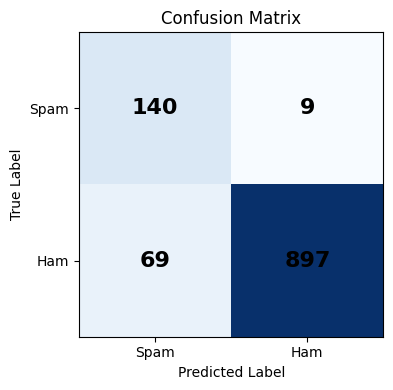

In [ ]:
def cosine_sim(a, b):
    """Cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return np.dot(a, b) / (norm_a * norm_b)

def classify_batch(projected_vecs, threshold=0.0):
    """
    Classify a batch of projected vectors.
    threshold: if (spam_sim - ham_sim) > threshold → SPAM
               Increase threshold to be more conservative (fewer false positives)
    """
    predictions = []
    for vec in projected_vecs:
        spam_sim = cosine_sim(vec, spam_centroid)
        ham_sim  = cosine_sim(vec, ham_centroid)
        pred = 'spam' if (spam_sim - ham_sim) > threshold else 'ham'
        predictions.append(pred)
    return np.array(predictions)

# Run on test set
true_labels = test_df['label'].values
predicted   = classify_batch(test_projected, threshold=0.0)

# Metrics
acc  = accuracy_score(true_labels, predicted)
prec = precision_score(true_labels, predicted, pos_label='spam')
rec  = recall_score(true_labels, predicted, pos_label='spam')
f1   = f1_score(true_labels, predicted, pos_label='spam')
cm   = confusion_matrix(true_labels, predicted, labels=['spam','ham'])

print("--- STEP 6: TEST SET EVALUATION ---")
print(f"Test set size: {len(true_labels)} messages (unseen during training)\n")
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%  (of predicted spam, how many were actually spam)")
print(f"Recall:    {rec*100:.2f}%  (of all spam, how many did we catch)")
print(f"F1 Score:  {f1*100:.2f}%  (harmonic mean of precision & recall)")
print(f"\nConfusion Matrix (rows=true, cols=predicted):")
print(f"           Pred:SPAM  Pred:HAM")
print(f"True:SPAM     {cm[0][0]:5d}     {cm[0][1]:5d}")
print(f"True:HAM      {cm[1][0]:5d}     {cm[1][1]:5d}")
print(f"\nFalse Positives (Ham marked as Spam): {cm[1][0]}")
print(f"False Negatives (Spam that slipped through): {cm[0][1]}")
print(f"\nFull classification report:")
print(classification_report(true_labels, predicted))

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')

# Label axes
ax.set_xticks([0,1]); ax.set_xticklabels(['Spam','Ham'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Spam','Ham'])
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")

# Print numbers inside boxes
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i][j], ha='center', va='center', fontsize=16, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

### STEP 7: Threshold Tuning

The decision threshold controls the **precision vs recall tradeoff**:
- **threshold = 0.0**: balanced
- **threshold > 0.0**: more conservative, fewer false spam alerts (higher precision)
- **threshold < 0.0**: more aggressive, catches more spam (higher recall)


In [ ]:
print("--- STEP 7: THRESHOLD TUNING ---")
print(f"{'Threshold':>10} | {'Accuracy':>9} | {'Precision':>9} | {'Recall':>9} | {'F1':>9}")
print("-" * 57)

for thresh in [-0.05, -0.02, 0.0, 0.02, 0.05, 0.10]:
    preds = classify_batch(test_projected, threshold=thresh)
    a = accuracy_score(true_labels, preds)
    p = precision_score(true_labels, preds, pos_label='spam', zero_division=0)
    r = recall_score(true_labels, preds, pos_label='spam', zero_division=0)
    f = f1_score(true_labels, preds, pos_label='spam', zero_division=0)
    print(f"{thresh:>10.2f} | {a*100:>8.2f}% | {p*100:>8.2f}% | {r*100:>8.2f}% | {f*100:>8.2f}%")

print("\nTip: Pick threshold=0.05 for fewer false alarms, -0.02 for maximum spam catch rate.")

--- STEP 7: THRESHOLD TUNING ---
 Threshold |  Accuracy | Precision |    Recall |        F1
---------------------------------------------------------
     -0.05 |    84.13% |    45.57% |    96.64% |    61.94%
     -0.02 |    87.00% |    50.71% |    95.97% |    66.36%
      0.00 |    93.00% |    66.99% |    93.96% |    78.21%
      0.02 |    94.71% |    73.68% |    93.96% |    82.60%
      0.05 |    95.43% |    78.49% |    90.60% |    84.11%
      0.10 |    96.14% |    87.32% |    83.22% |    85.22%

Tip: Pick threshold=0.05 for fewer false alarms, -0.02 for maximum spam catch rate.


### STEP 8: Interactive Classifier

Full single-message classifier with explicit math shown at each step.

In [ ]:
def classify_message(new_text, threshold=0.0, verbose=True):
    """
    Classify a new message using LSA + centroid cosine similarity.

    Math pipeline:
      1. TF-IDF vectorize: text → high-dim sparse vector q
      2. Project into latent space: q_k = q · V  (orthogonal projection onto k-dim subspace)
      3. Cosine similarity vs centroids: sim = (q_k · c) / (||q_k|| ||c||)
      4. Classify: spam if (sim_spam - sim_ham) > threshold
    """
    # Step 1: TF-IDF
    tfidf_vec = vectorizer.transform([new_text]).toarray()[0]  # shape: (vocab,)

    # Step 2: Project into k-dim latent space (orthogonal projection)
    # V = svd.components_.T  shape: (vocab, k)
    projected = svd.transform(vectorizer.transform([new_text]))[0]  # shape: (k,)

    # Step 3: Cosine similarity vs each centroid
    spam_sim = cosine_sim(projected, spam_centroid)
    ham_sim  = cosine_sim(projected, ham_centroid)
    margin   = spam_sim - ham_sim

    # Step 4: Decision
    label = 'spam' if margin > threshold else 'ham'

    if verbose:
        print(f"\n--- CLASSIFYING ---")
        print(f"Message: '{new_text}'")
        print(f"Projected coords (first 5 dims): {np.round(projected[:5], 4)}")
        print(f"Cosine sim → SPAM centroid: {spam_sim:.4f}")
        print(f"Cosine sim → HAM  centroid: {ham_sim:.4f}")
        print(f"Decision margin (spam-ham): {margin:+.4f}  (threshold={threshold})")
        if label == 'spam':
            print(f"🚨 RESULT: SPAM  (margin={margin:+.4f} > {threshold})")
        else:
            print(f"✅ RESULT: HAM   (margin={margin:+.4f} ≤ {threshold})")

    return label

# --- Test with examples ---
classify_message("Urgent! Click here to claim your FREE cash prize NOW!!!")
classify_message("Hey, are you coming to class tomorrow? ")
classify_message("You have won a £1000 prize. Call 08000930705 to claim.")
classify_message("Can we reschedule our meeting to Friday afternoon?")
classify_message("CONGRATULATIONS! You've been selected for a FREE holiday. Reply YES")


--- CLASSIFYING ---
Message: 'Urgent! Click here to claim your FREE cash prize NOW!!!'
Projected coords (first 5 dims): [ 0.2184 -0.0926 -0.1556  0.1047 -0.0575]
Cosine sim → SPAM centroid: 0.5630
Cosine sim → HAM  centroid: 0.0229
Decision margin (spam-ham): +0.5401  (threshold=0.0)
🚨 RESULT: SPAM  (margin=+0.5401 > 0.0)

--- CLASSIFYING ---
Message: 'Hey, are you coming to class tomorrow? '
Projected coords (first 5 dims): [0.0488 0.0124 0.071  0.0189 0.0069]
Cosine sim → SPAM centroid: 0.0135
Cosine sim → HAM  centroid: 0.2132
Decision margin (spam-ham): -0.1997  (threshold=0.0)
✅ RESULT: HAM   (margin=-0.1997 ≤ 0.0)

--- CLASSIFYING ---
Message: 'You have won a £1000 prize. Call 08000930705 to claim.'
Projected coords (first 5 dims): [ 0.1425 -0.0725 -0.1681  0.1737 -0.059 ]
Cosine sim → SPAM centroid: 0.3827
Cosine sim → HAM  centroid: -0.0001
Decision margin (spam-ham): +0.3828  (threshold=0.0)
🚨 RESULT: SPAM  (margin=+0.3828 > 0.0)

--- CLASSIFYING ---
Message: 'Can we reschedu

'spam'